In [1]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Week 6 Assessment
## Autoencoder for Image Denoising using MNIST Dataset

**Name:** Priysha

**Project Objective:**
The objective of this project is to build a convolutional autoencoder that removes noise from handwritten digit images using the MNIST dataset. The model learns to reconstruct clean images from noisy inputs.

In [2]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D

from tensorflow.keras.models import Model

In [3]:
# Load MNIST dataset

(x_train, _), (x_test, _) = mnist.load_data()

In [4]:
print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


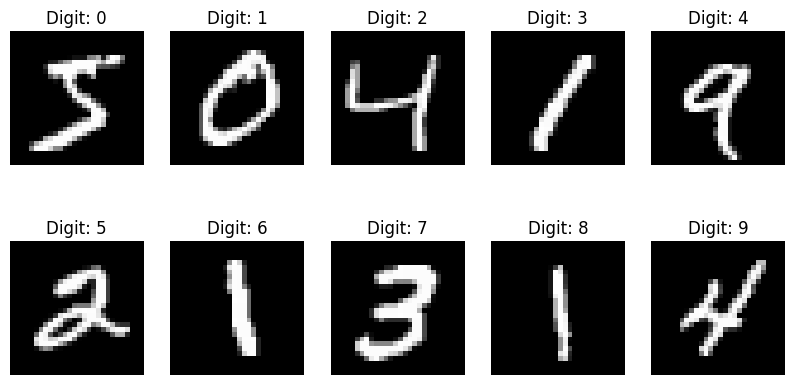

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Digit: {i}")
    plt.axis("off")

plt.show()

### Dataset Visualization

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9. Each image has a size of 28 × 28 pixels. The above visualization shows sample images from the training dataset.

### Data Preprocessing

The pixel values of the images are normalized from the range **0–255** to **0–1** by dividing each pixel value by 255. This helps the neural network train faster and improves model performance.

In [6]:
# Normalize the images

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

### Reshaping the Images

The images are reshaped to include a channel dimension. Since MNIST images are grayscale, each image has one channel, resulting in a shape of **28 × 28 × 1**.

In [7]:
# Reshape images

x_train = x_train.reshape((len(x_train), 28, 28, 1))
x_test = x_test.reshape((len(x_test), 28, 28, 1))

In [8]:
print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


### Adding Gaussian Noise

To train the autoencoder, Gaussian noise is added to the original images. The noisy images are used as input, while the original clean images serve as the target output during training.

In [9]:
# Noise factor

noise_factor = 0.5

# Add noise to training images

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Add noise to testing images

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [10]:
# Clip values between 0 and 1

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

### Original vs Noisy Images

The following images compare the original MNIST digits with the corresponding noisy versions generated using Gaussian noise.

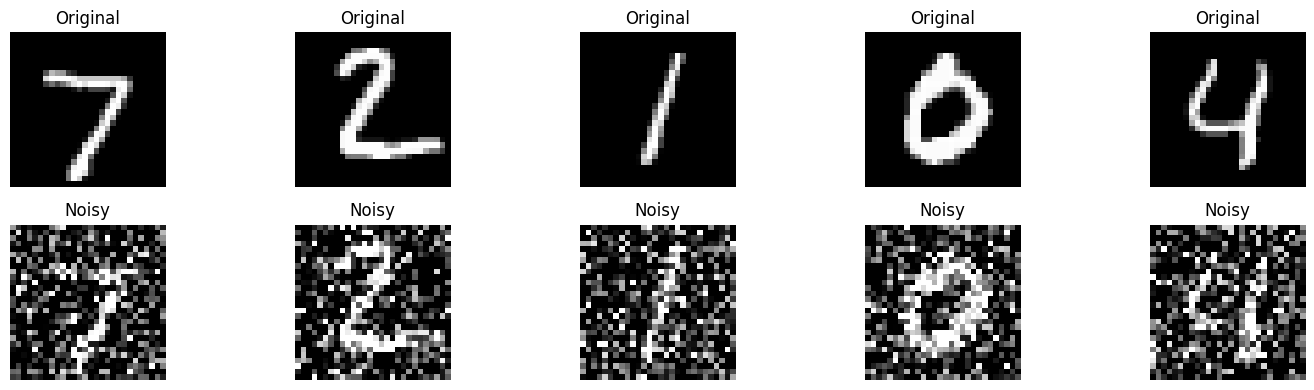

In [11]:
plt.figure(figsize=(15, 4))

for i in range(5):

    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Building the Convolutional Autoencoder

An autoencoder is a neural network that learns to reconstruct its input. It consists of two main parts:

- **Encoder:** Compresses the input image into a smaller feature representation.
- **Decoder:** Reconstructs the original image from the compressed representation.

In this project, the model learns to reconstruct clean handwritten digit images from noisy input images.

In [12]:
# Input layer

input_img = Input(shape=(28, 28, 1))

# ==========================
# Encoder
# ==========================

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# ==========================
# Decoder
# ==========================

x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Create the model

autoencoder = Model(input_img, decoded)

### Model Compilation

The autoencoder is compiled using the Adam optimizer and Binary Crossentropy loss function. The Adam optimizer efficiently updates the model weights, while Binary Crossentropy measures the reconstruction error between the original and predicted images.

In [13]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [14]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The autoencoder is trained using noisy images as the input and clean images as the target output. During training, the model learns to remove noise and reconstruct the original handwritten digits.

In [15]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - loss: 0.1600 - val_loss: 0.1162
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.1130 - val_loss: 0.1083
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.1077 - val_loss: 0.1048
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.1048 - val_loss: 0.1031
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.1029 - val_loss: 0.1012
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.1015 - val_loss: 0.1001
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.1006 - val_loss: 0.0997
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.0998 - val_loss: 0.0991
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.0991 - val_loss: 0.0985
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.0984 - val_loss: 0.0976
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.0980 - val_loss: 0.0972
Epoch 12/20
469/469 ━━━━━━━━━━

## Training Performance

The graph below shows the training loss and validation loss over each epoch. A decreasing loss indicates that the autoencoder is learning to reconstruct clean images from noisy inputs.

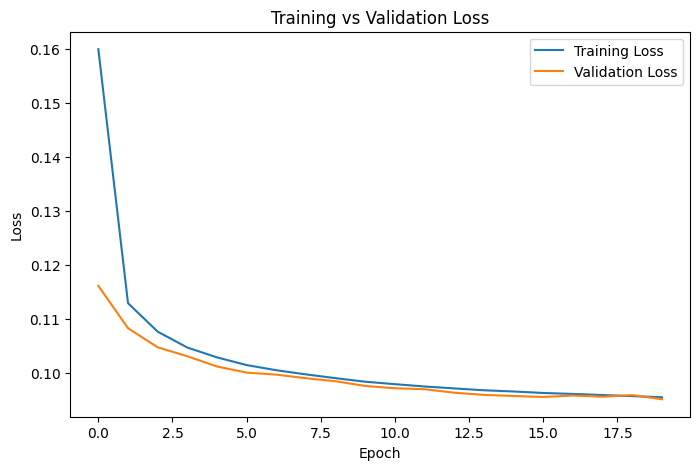

In [16]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Image Reconstruction

The trained autoencoder is used to reconstruct clean images from the noisy test images.

In [17]:
# Generate denoised images

decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


## Original vs Noisy vs Denoised Images

The following images compare the original handwritten digits, the noisy input images, and the denoised images produced by the autoencoder.

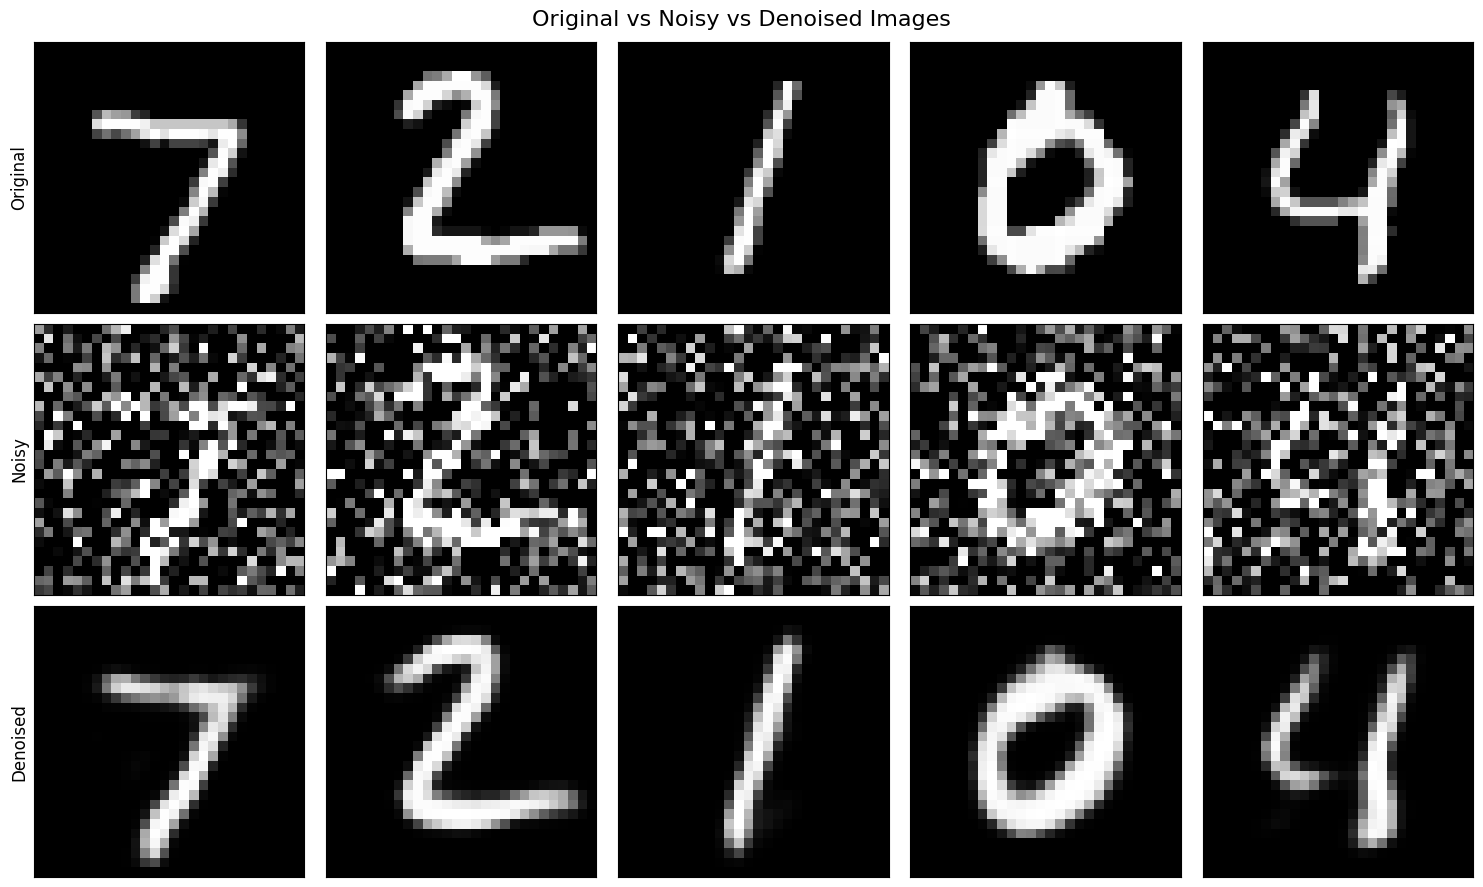

In [18]:
n = 5

plt.figure(figsize=(15, 9))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    if i == 0:
        ax.set_ylabel("Original", fontsize=12)
    plt.xticks([])
    plt.yticks([])

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    if i == 0:
        ax.set_ylabel("Noisy", fontsize=12)
    plt.xticks([])
    plt.yticks([])

    # Denoised
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    if i == 0:
        ax.set_ylabel("Denoised", fontsize=12)
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Original vs Noisy vs Denoised Images", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
autoencoder.save("week6_Priysha_autoencoder.keras")

# Conclusion

In this project, a Convolutional Autoencoder was developed to remove Gaussian noise from MNIST handwritten digit images. The model was trained using noisy images as input and clean images as the target output. The training and validation loss decreased consistently, indicating successful learning. The reconstructed images demonstrate that the autoencoder effectively removed most of the noise while preserving the original digit structure. This project highlights the effectiveness of autoencoders for image denoising tasks.